# The Resource-Consumer NP Model With Odeint

In [2]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

The code below represents the dynamics
$$\frac{dN}{dt}=-k NP$$
$$\frac{dP}{dt}=k NP$$
The parameter $k$ is an input to the function

In [3]:
# function that returns the right hand side of the above equations
def model(state,t,k):
    N,P = state
    Ndot = -k * N * P
    Pdot =  k * N * P
    return np.array([Ndot,Pdot])

Set the initial conditions, the time axis and solve the ODE

In [4]:
# initial conditions
K = 0.1
N0 = 5.0
P0 = 0.1
state0 = np.array([N0,P0])

# time points (days)
t = np.linspace(0,20,num=100)

# solve ODE using odeint (remember that args is a tuple)
y = odeint(model,state0,t,args=(K,))

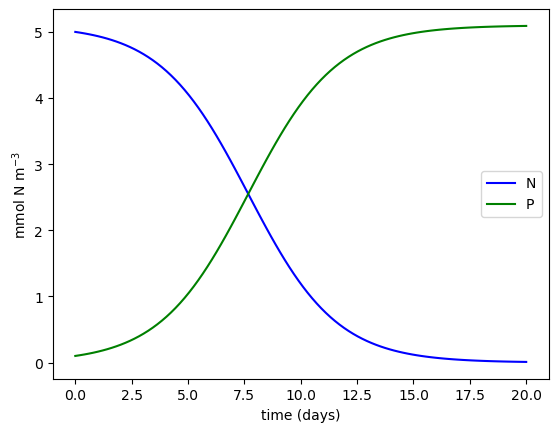

In [5]:
# plot the resulting time series
plt.plot(t,y[:,0],'b',label='N')
plt.plot(t,y[:,1],'g',label='P')
plt.xlabel('time (days)')
plt.ylabel('mmol N m$^{-3}$')
plt.legend()
plt.show()

## Ocean Modelling: Exercise 7
Compare the analytical solution of the model presented in Eq.(4) from Exercise 2 with the numerical solution obtained using odeint in file NP to NPD.ipynb. Check the code carefully to understand how the right-end-side of the dynamical equation is implemented. 
- Modify the notebook to answer the following questions and upload it on your repository:
1. What are the inputs and outputs in the function model? What kind of objects are they?

The inputs are the initial conditions which include: K (growth rate/consumption rate parameter/constant), N0 (initial nutrient concentration) and P0 (initial phytoplankton biomass). N0 and P0 are used to create an array of initial conditions at t0. The outputs include the new values for N and P after consumption/growth defined by K over time. These values of N and P also form an array.

3. Write the equtions for a new model to simulate the nutrient-phytoplankton-detritus system (NPD). You will Include a
detritus variable D that is produced from the mortality of phytoplankton and it is remineralized as a nutrient. You will need 2 additional parameters: the mortality rate (phytoplankton lysis) and the remineralization rate.
4. Write the code to solve the new model using odeint and propose some reasonable values for the parameters that lead to
a realistic solution.

#### Exercise
2. Write a new model to simulate the nutrient-phytoplankton-detritus system (NPD). Include a detritus variable D that is produced from the mortality of phytoplankton and it is remineralized as a nutrient. This will involve adding 2 new parameters: the mortality rate (phytoplankton lysis) and the remineralization rate.

The model equations can be written using latex. Check the code in the inital cell above. Otherwise you can use the equation editor on Word or LibreOffice.

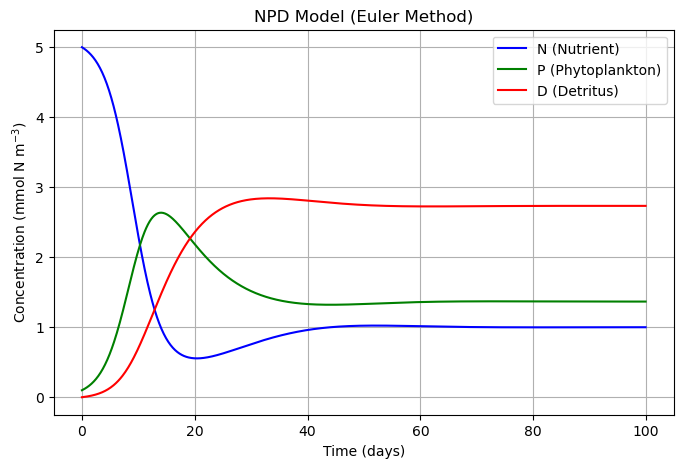

In [16]:
import numpy as np
import matplotlib.pyplot as plt

# PARAMETERS
k = 0.1      # uptake rate
m = 0.1      # phytoplankton mortality (lysis)
r = 0.05     # remineralization rate

dt = 0.1
T = 100
t = np.arange(0, T, dt)

# INITIAL CONDITIONS
N = np.zeros(len(t))
P = np.zeros(len(t))
D = np.zeros(len(t))
N[0] = 5.0
P[0] = 0.1
D[0] = 0.0

# EULER TIME STEPPING
for i in range(1, len(t)):
    Ndot = -k * N[i-1] * P[i-1] + r * D[i-1]
    Pdot =  k * N[i-1] * P[i-1] - m * P[i-1]
    Ddot =  m * P[i-1] - r * D[i-1]

    N[i] = N[i-1] + dt * Ndot
    P[i] = P[i-1] + dt * Pdot
    D[i] = D[i-1] + dt * Ddot

# PLOT
plt.figure(figsize=(8,5))

plt.plot(t, N, 'b', label='N (Nutrient)')
plt.plot(t, P, 'g', label='P (Phytoplankton)')
plt.plot(t, D, 'r', label='D (Detritus)')

plt.xlabel('Time (days)')
plt.ylabel('Concentration (mmol N m$^{-3}$)')
plt.title('NPD Model (Euler Method)')
plt.legend()
plt.grid(True)

plt.show()

3. Write the code to solve the new model using odeint and propose some reasonable values for the parameters that lead to a realistic solution

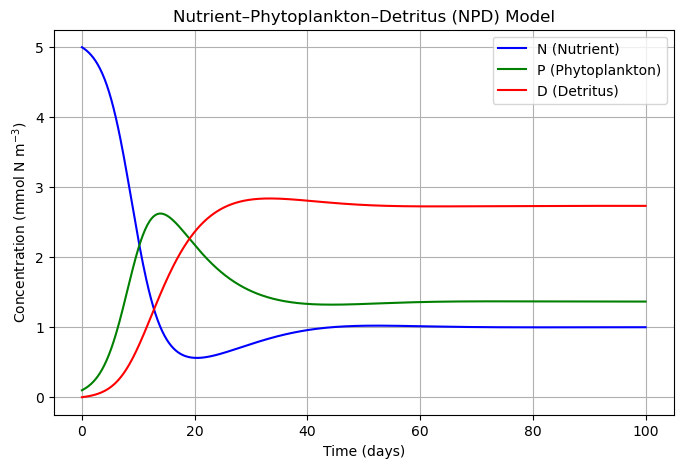

In [14]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt

# NPD MODEL
def model(state, t, k, m, r):
    N, P, D = state

    Ndot = -k * N * P + r * D
    Pdot =  k * N * P - m * P
    Ddot =  m * P - r * D

    return np.array([Ndot, Pdot, Ddot])

# PARAMETERS
k = 0.1      # uptake rate
m = 0.1      # phytoplankton mortality (lysis)
r = 0.05     # remineralization rate

# INITIAL CONDITIONS
N0 = 5.0
P0 = 0.1
D0 = 0.0
state0 = np.array([N0, P0, D0])

# TIME
t = np.linspace(0, 100, num=500)

# SOLVE ODE
solution = odeint(model, state0, t, args=(k, m, r))
N = solution[:,0]
P = solution[:,1]
D = solution[:,2]

# PLOT
plt.figure(figsize=(8,5))

plt.plot(t, N, 'b', label='N (Nutrient)')
plt.plot(t, P, 'g', label='P (Phytoplankton)')
plt.plot(t, D, 'r', label='D (Detritus)')

plt.xlabel('Time (days)')
plt.ylabel('Concentration (mmol N m$^{-3}$)')
plt.title('Nutrient–Phytoplankton–Detritus (NPD) Model')
plt.legend()
plt.grid(True)

plt.show()